In [1]:
import numpy as np
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
import networkx as nx
from qiskit.quantum_info import SparsePauliOp
from scipy.optimize import minimize
from qiskit.circuit.library import QAOAAnsatz
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

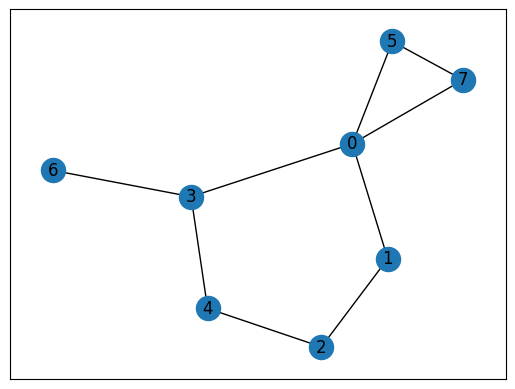

In [2]:
G = nx.Graph()
G.add_edges_from([[0,1],[0,3],[0,5],[0,7],[5,7],[1,2],[2,4],[3,4],[3,6]])
nx.draw_networkx(G)

In [3]:
operator = SparsePauliOp.from_list(
    [("IIIIIIZZ", 0.5), 
     ("IIIIZIIZ", 0.5), 
     ("IIZIIIIZ", 0.5), 
     ("ZIIIIIIZ", 0.5), 
     ("ZIZIIIII", 0.5), 
     ("IIIIIZZI", 0.5), 
     ("IIIZIZII", 0.5), 
     ("IIIZZIII", 0.5), 
     ("IZIIZIII", 0.5),]
)

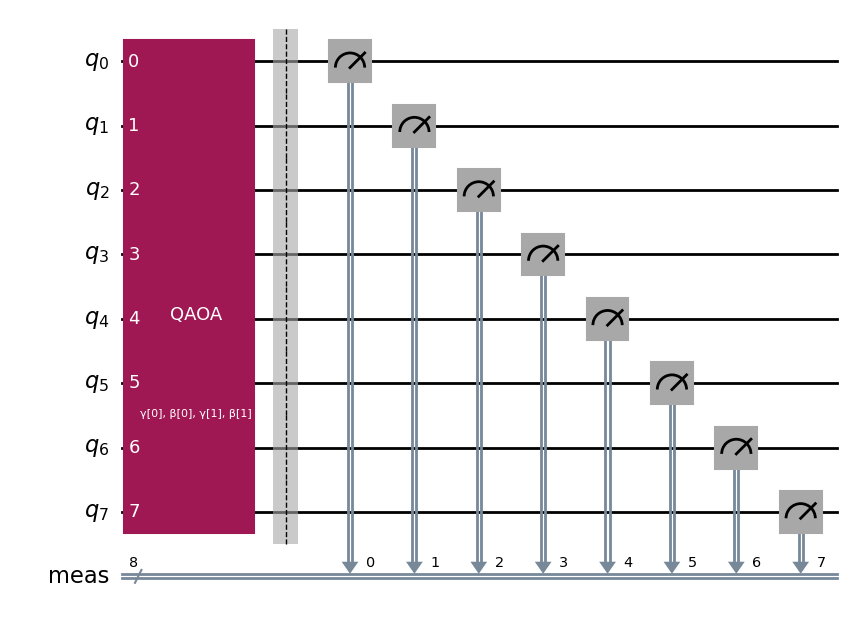

In [4]:
circuit = QAOAAnsatz(cost_operator=operator, reps=2)
circuit.measure_all()

circuit.draw('mpl')

In [5]:
my_backend = GenericBackendV2(num_qubits=8)

In [6]:
def cost_func(params, ansatz, hamiltonian, estimator):
    mapped_hamiltonian = hamiltonian.apply_layout(ansatz.layout)
    pub = (ansatz, mapped_hamiltonian, params)
    job = estimator.run([pub])
    results = job.result()[0]
    cost = results.data.evs
    costs.append(cost)
    print(len(costs), cost)
    return cost

In [7]:
num_params = circuit.num_parameters
x0 = np.pi * np.random.random(num_params)

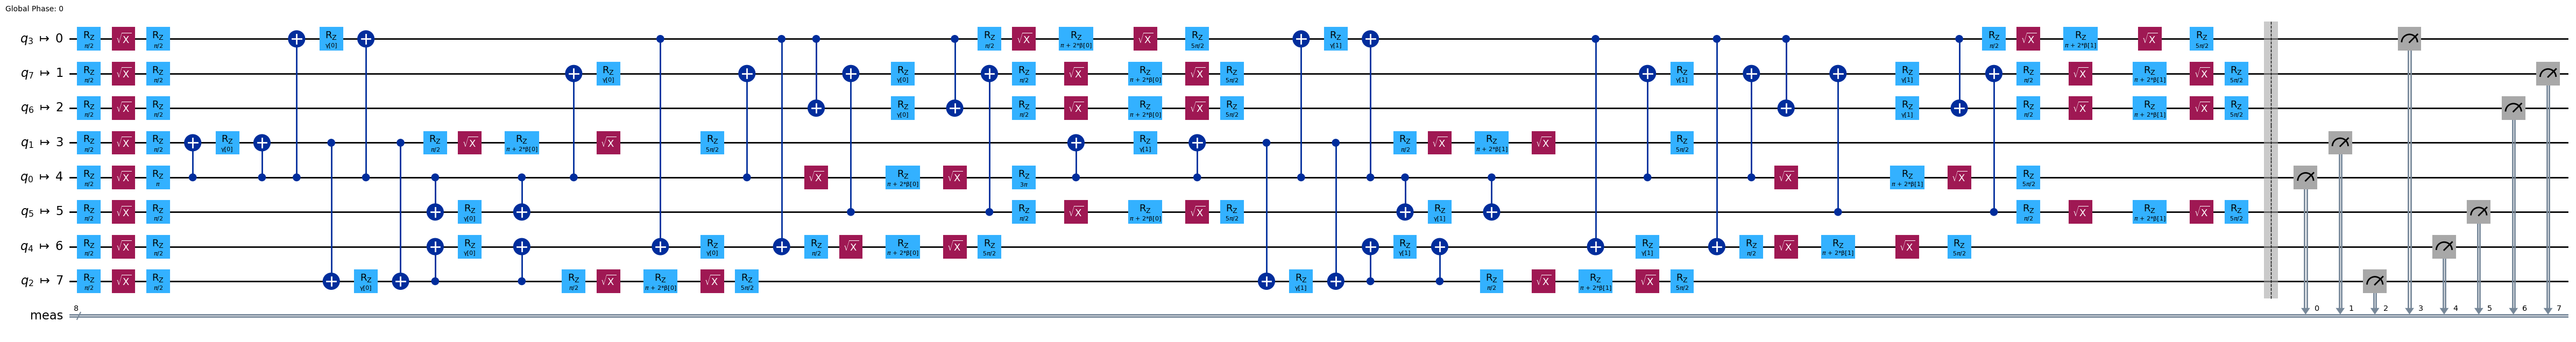

In [8]:
pm = generate_preset_pass_manager(optimization_level=3,
                                    backend=my_backend)

transpiled_circuit = pm.run(circuit)
transpiled_circuit.draw('mpl', fold=False, idle_wires=False)

In [9]:
costs = []
with Session(backend=my_backend) as session:
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 10000

    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"
    
    result = minimize(
        cost_func,
        x0,
        args=(transpiled_circuit, operator, estimator),
        method="COBYLA",
        tol=1e-2,
    )
    print(result)

C:\Users\TomaszStopa\miniforge3\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:274: UserWarning: Options {'dynamical_decoupling': {'enable': True, 'sequence_type': 'XY4'}, 'twirling': {'enable_gates': True, 'num_randomizations': 'auto'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


1 -0.21589999999999998


C:\Users\TomaszStopa\miniforge3\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:274: UserWarning: Options {'dynamical_decoupling': {'enable': True, 'sequence_type': 'XY4'}, 'twirling': {'enable_gates': True, 'num_randomizations': 'auto'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


2 0.018100000000000012


C:\Users\TomaszStopa\miniforge3\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:274: UserWarning: Options {'dynamical_decoupling': {'enable': True, 'sequence_type': 'XY4'}, 'twirling': {'enable_gates': True, 'num_randomizations': 'auto'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


...

35 -1.0583


C:\Users\TomaszStopa\miniforge3\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:274: UserWarning: Options {'dynamical_decoupling': {'enable': True, 'sequence_type': 'XY4'}, 'twirling': {'enable_gates': True, 'num_randomizations': 'auto'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


36 -1.0556999999999999


C:\Users\TomaszStopa\miniforge3\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:274: UserWarning: Options {'dynamical_decoupling': {'enable': True, 'sequence_type': 'XY4'}, 'twirling': {'enable_gates': True, 'num_randomizations': 'auto'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


37 -1.0607999999999997
 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -1.0607999999999997
       x: [ 1.300e+00  4.522e-01  1.583e+00  7.607e-01]
    nfev: 37
   maxcv: 0.0


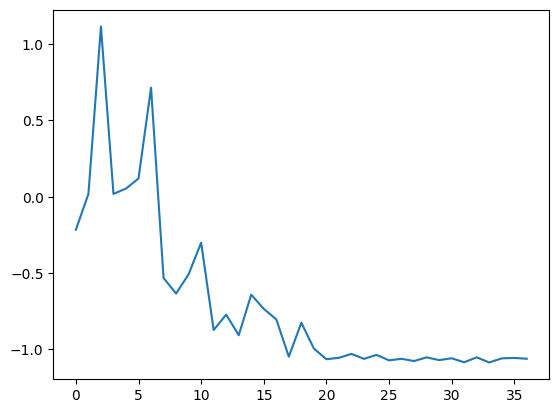

In [10]:
import matplotlib.pyplot as plt
plt.plot(costs)

In [11]:
optimized_circuit = transpiled_circuit.assign_parameters(result.x)

In [12]:
shots = 10000

sampler = Sampler(mode=my_backend)
sampler.options.default_shots = shots

pub= (optimized_circuit, )
job = sampler.run([pub], shots=shots)
counts_int = job.result()[0].data.meas.get_int_counts()
counts = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val / shots for key, val in counts_int.items()}

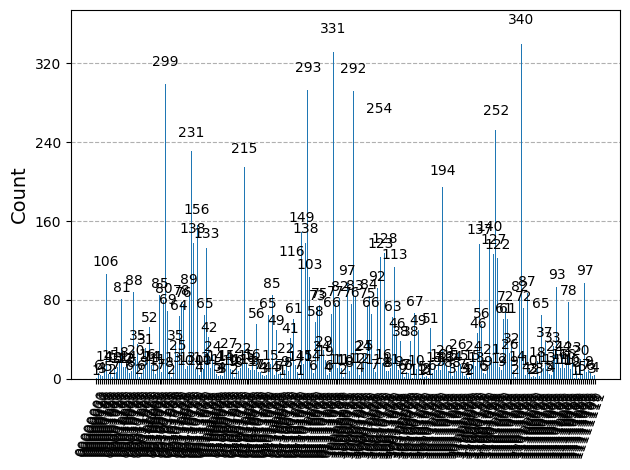

In [13]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

In [14]:
# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]
 
keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, G.number_of_nodes())
most_likely_bitstring.reverse()
 
print("Result bitstring:", most_likely_bitstring)

Result bitstring: [0, 1, 0, 1, 1, 0, 1, 1]


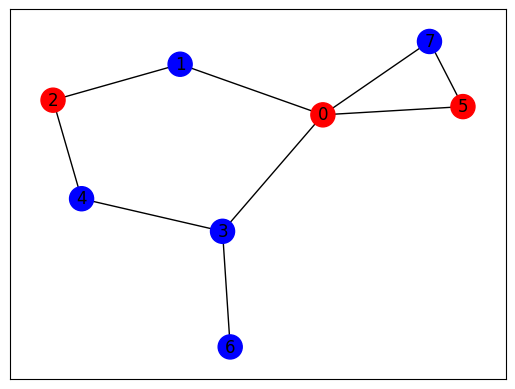

In [15]:
colors = ['r' if most_likely_bitstring[node] == 0 else 'b' for node in G]
nx.draw_networkx(G,node_color = colors)

## Exercise
* Define your own 8-node graph and use 'frute-force' method to find MAX-CUT for it (checking all color possibilities and choosing the one with max cut).
* Use Qiskit to run QAOA algorithm to solve MAX-CUT problem for the same graph, run it on simulator and compare result with brute-force.
* Run the QAOA algorithm on real backend and compare results.

This link may be helpful: https://quantum.cloud.ibm.com/docs/en/tutorials/quantum-approximate-optimization-algorithm